<a href="https://colab.research.google.com/github/ExTc-aShiSh/Introduction-to-AI/blob/main/MxPT_by_HCA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Optimal Load Resistance (RL): 4 Ohms
Maximum Power Delivered: 6.25 Watts


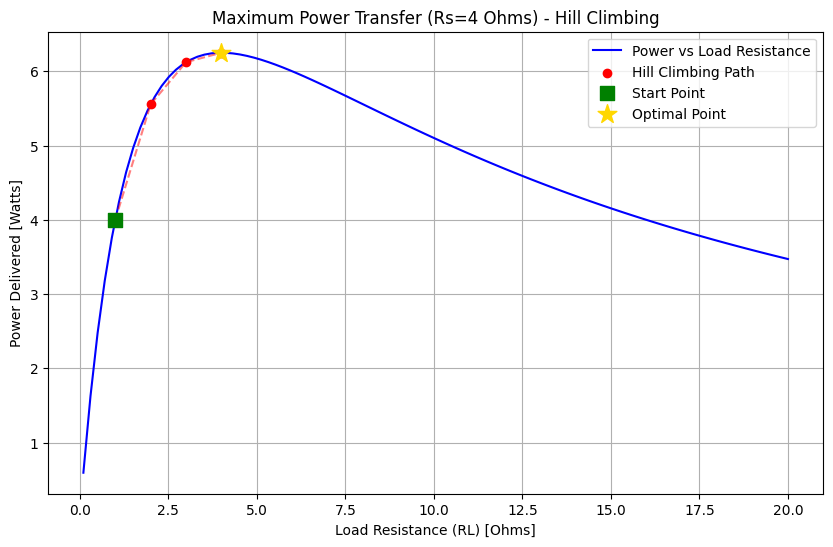

In [3]:
import matplotlib.pyplot as plt
import numpy as np

# Hill Climbing for Maximum Power Transfer

# Given values
V = 10          # Source voltage (Volts)
Rs = 4          # Source resistance (Ohms)

# Objective function: Power delivered to load
def power(RL):
    return (V**2 * RL) / ((Rs + RL)**2)

# Hill Climbing Algorithm
RL = 1          # Initial guess
step = 1        # Step size

# Store history
history_RL = []
history_Power = []

while True:
    current_power = power(RL)
    history_RL.append(RL)
    history_Power.append(current_power)

    # Check neighbors
    forward_power = power(RL + step)
    backward_power = power(RL - step) if RL - step > 0 else -1

    # Move to better neighbor
    if forward_power > current_power:
        RL = RL + step
    elif backward_power > current_power:
        RL = RL - step
    else:
        break  # Stop if no improvement

# Output result
print("Optimal Load Resistance (RL):", RL, "Ohms")
print("Maximum Power Delivered:", round(power(RL), 4), "Watts")

# Visualization
# Generate data for the power curve
x = np.linspace(0.1, 20, 100)
y = [power(r) for r in x]

plt.figure(figsize=(10, 6))
plt.plot(x, y, label='Power vs Load Resistance', color='blue')
plt.scatter(history_RL, history_Power, color='red', label='Hill Climbing Path', zorder=5)
plt.plot(history_RL, history_Power, color='red', linestyle='--', alpha=0.5)

# Highlight start and end points
plt.scatter(history_RL[0], history_Power[0], color='green', marker='s', s=100, label='Start Point', zorder=6)
plt.scatter(history_RL[-1], history_Power[-1], color='gold', marker='*', s=200, label='Optimal Point', zorder=6)

plt.title(f'Maximum Power Transfer (Rs={Rs} Ohms) - Hill Climbing')
plt.xlabel('Load Resistance (RL) [Ohms]')
plt.ylabel('Power Delivered [Watts]')
plt.legend()
plt.grid(True)
plt.show()
